# JAXSEDFit And GRAHSP Chimera Parameter Trace Plots

This notebook fits one Chimera benchmark object, selected by object id, and plots parameter traces for both `jaxsedfit` and the original GRAHSP system. The `jaxsedfit` section uses `optax+nuts` by default because trace plots are most useful for MCMC draws; the GRAHSP section plots ordered UltraNest dead/posterior samples from its chain files.

## Setup

Run this notebook from `jaxsedfit/notebooks`. The default DSPS SSP file path is `../tempdata.h5` relative to the `jaxsedfit` checkout.

In [11]:
from pathlib import Path
import math
import os
import subprocess
import sys
import textwrap

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
from astropy.table import Table


def find_jaxsedfit_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "src" / "jaxsedfit").is_dir():
            return path
        nested = path / "jaxsedfit"
        if (nested / "src" / "jaxsedfit").is_dir():
            return nested
    raise RuntimeError("Could not find the jaxsedfit repository root")


def find_grahsp_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "jaxsedfit" / "src").is_dir() and (path / "sampler" / "dualsampler.py").is_file():
            return path
        if (path / "src" / "jaxsedfit").is_dir() and (path.parent / "sampler" / "dualsampler.py").is_file():
            return path.parent
    raise RuntimeError("Could not find the original GRAHSP repository root")


project_root = find_jaxsedfit_root()
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from jaxsedfit.benchmark import build_chimera_fit_config, load_chimera_benchmark_dataset
from jaxsedfit.core import JAXSEDFit
from jaxsedfit.mplstyle import style_path

plt.style.use(style_path())
grahsp_root = find_grahsp_root(project_root)
cigale_root = grahsp_root / "cigale"
sampler_script = grahsp_root / "sampler" / "dualsampler.py"

print("jaxsedfit root:", project_root)
print("grahsp root:", grahsp_root)
print("grahsp sampler:", sampler_script)

jaxsedfit root: /home/nicho/GRAHSP/jaxsedfit
grahsp root: /home/nicho/GRAHSP
grahsp sampler: /home/nicho/GRAHSP/sampler/dualsampler.py


## Pick A Chimera Object

Change `target_object_id` to any id in the full Chimera benchmark table.

In [12]:
dsps_ssp_fn = project_root / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

dataset = load_chimera_benchmark_dataset(project_root)
print(f"Loaded {len(dataset.rows)} Chimera benchmark rows")
print("Example object IDs:", [str(r["id"]) for r in dataset.rows[:5]])

target_object_id = "074738.39+245637.3_315709_0.0001"

row = next((r for r in dataset.rows if str(r["id"]) == target_object_id), None)
if row is None:
    raise ValueError(f"target_object_id={target_object_id!r} was not found")

truth_logm = float(row["log_stellar_mass_truth"])
print("Selected object_id:", row["id"])
print("redshift:", row["redshift"])
print("truth log stellar mass:", truth_logm)

[benchmark] Loading Chimera photometry from /home/nicho/GRAHSP/jaxsedfit/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /home/nicho/GRAHSP/jaxsedfit/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
Loaded 18168 Chimera benchmark rows
Example object IDs: ['011521.37+311730.6_386291_0.0003', '011529.24+321114.9_810483_0.001', '011601.41+322234.8_270428_0.3', '011601.41+322234.8_325694_0.1', '011601.41+322234.8_339240_0.03']
Selected object_id: 074738.39+245637.3_315709_0.0001
redshift: 0.12319999933242798
truth log stellar mass: 9.08123


## Run The Fit

The defaults below are modest notebook settings. Increase `NUTS_WARMUP` and `NUTS_SAMPLES` for production diagnostics.

In [13]:
FIT_METHOD = "optax+nuts"
MAP_STEPS = 400
LEARNING_RATE = 5e-3
NUTS_WARMUP = 1000
NUTS_SAMPLES = 1000
NUTS_CHAINS = 2
TARGET_ACCEPT_PROB = 0.95

cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))
cfg.inference.map_steps = MAP_STEPS
cfg.inference.learning_rate = LEARNING_RATE
cfg.inference.num_warmup = NUTS_WARMUP
cfg.inference.num_samples = NUTS_SAMPLES
cfg.inference.num_chains = NUTS_CHAINS
cfg.inference.target_accept_prob = TARGET_ACCEPT_PROB

cfg.inference.method = FIT_METHOD
fitter = JAXSEDFit(cfg)
fit_result = fitter.fit(
    prior_config=cfg.prior_config,
    dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
    optax_steps=cfg.inference.map_steps,
    optax_lr=cfg.inference.learning_rate,
    nuts_warmup=cfg.inference.num_warmup,
    nuts_samples=cfg.inference.num_samples,
    nuts_chains=cfg.inference.num_chains,
    target_accept_prob=cfg.inference.target_accept_prob,
    plot_fig=False,
    save_fig=False,
    save_result=False,
    progress_bar=True,
)

logm_samples = np.asarray(fitter.samples["log_stellar_mass"], dtype=float).reshape(-1)
logm16, recovered_logm, logm84 = np.percentile(logm_samples, [16.0, 50.0, 84.0])

print("object_id:", row["id"])
print("truth log stellar mass:", truth_logm)
print("recovered log stellar mass:", recovered_logm)
print("recovered 16-84% range:", (logm16, logm84))
print("residual:", recovered_logm - truth_logm)

100%|██████████| 400/400 [00:04<00:00, 90.95it/s, init loss: 402.2052, avg. loss [381-400]: 175.9861] 
/home/nicho/GRAHSP/jaxsedfit/src/jaxsedfit/core.py:453: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains, progress_bar=progress_bar, jit_model_args=False)
sample: 100%|██████████| 2000/2000 [07:35<00:00,  4.39it/s, 255 steps of size 9.89e-03. acc. prob=0.90]


object_id: 074738.39+245637.3_315709_0.0001
truth log stellar mass: 9.08123
recovered log stellar mass: 6.765529487549011
recovered 16-84% range: (np.float64(6.516419300138316), np.float64(7.11116600540437))
residual: -2.315700512450989


## Build Trace Columns

For NUTS fits, traces are grouped by chain when available. Scalar parameters are plotted directly; vector-valued parameters are split into labeled components.

In [14]:
def get_trace_samples(fitter):
    if FIT_METHOD in {"nuts", "optax+nuts"} and fitter.nuts_result is not None:
        return fitter.nuts_result["mcmc"].get_samples(group_by_chain=True)
    return {name: np.asarray(value)[None, ...] for name, value in fitter.samples.items()}


def flatten_trace_columns(samples, drop_constant=True, include_vector_components=True):
    columns = []
    dropped = []

    for name in sorted(samples):
        arr = np.asarray(samples[name], dtype=float)
        if arr.ndim == 1:
            arr = arr[None, :, None]
        elif arr.ndim == 2:
            arr = arr[:, :, None]
        elif arr.ndim >= 3:
            if not include_vector_components:
                dropped.append((name, "vector parameter"))
                continue
            arr = arr.reshape(arr.shape[0], arr.shape[1], -1)
        else:
            dropped.append((name, "unsupported shape"))
            continue

        for j in range(arr.shape[-1]):
            y = arr[:, :, j]
            label = name if arr.shape[-1] == 1 else f"{name}[{j}]"
            if not np.all(np.isfinite(y)):
                dropped.append((label, "non-finite values"))
                continue
            if drop_constant and np.nanmax(y) - np.nanmin(y) <= 1e-10:
                dropped.append((label, "constant"))
                continue
            columns.append((label, y))

    return columns, dropped


trace_samples = get_trace_samples(fitter)
trace_columns, dropped_trace_columns = flatten_trace_columns(trace_samples)

print(f"Trace parameters/components plotted: {len(trace_columns)}")
if dropped_trace_columns:
    print(f"Dropped {len(dropped_trace_columns)} constant or unsupported entries")
    print(dropped_trace_columns[:20])

Trace parameters/components plotted: 53
Dropped 2088 constant or unsupported entries
[('agn_variability_nev', 'constant'), ('host_capture_fraction_fluxes[0]', 'constant'), ('host_capture_fraction_fluxes[1]', 'constant'), ('host_capture_fraction_fluxes[2]', 'constant'), ('host_capture_fraction_fluxes[3]', 'constant'), ('host_capture_fraction_fluxes[4]', 'constant'), ('host_capture_fraction_fluxes[5]', 'constant'), ('host_capture_fraction_fluxes[6]', 'constant'), ('host_capture_fraction_fluxes[7]', 'constant'), ('host_capture_fraction_fluxes[8]', 'constant'), ('host_capture_slope_fit', 'constant'), ('host_total_fluxes[0]', 'constant'), ('host_total_fluxes[1]', 'constant'), ('host_total_fluxes[2]', 'constant'), ('host_total_fluxes[3]', 'constant'), ('host_total_fluxes[4]', 'constant'), ('host_total_fluxes[5]', 'constant'), ('host_total_fluxes[6]', 'constant'), ('host_total_fluxes[7]', 'constant'), ('host_total_fluxes[8]', 'constant')]


## Plot Parameter Traces

Each subplot shows sample number on the x-axis. When multiple chains are available, each chain is drawn as a separate line.

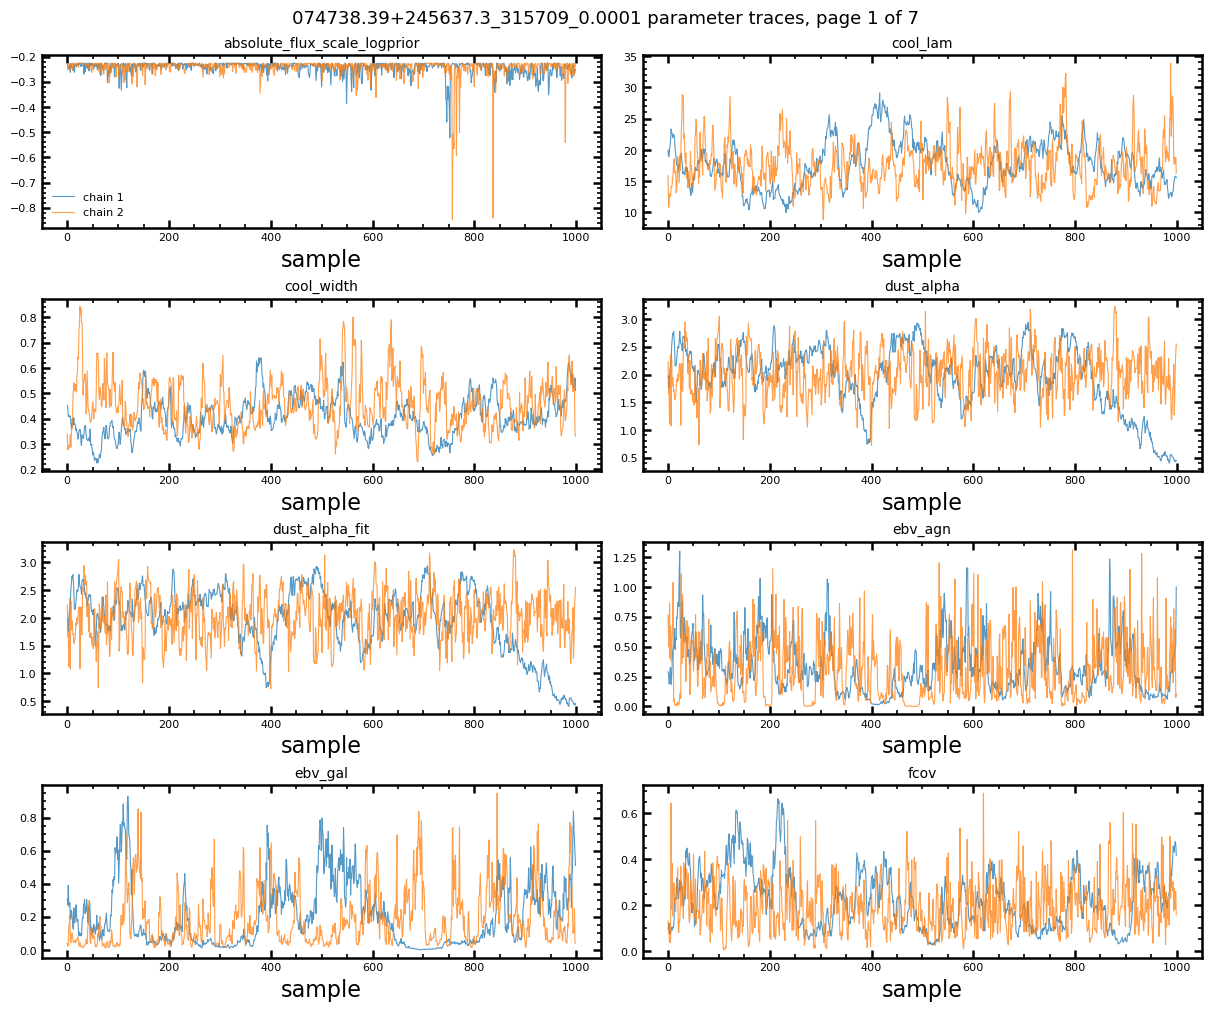

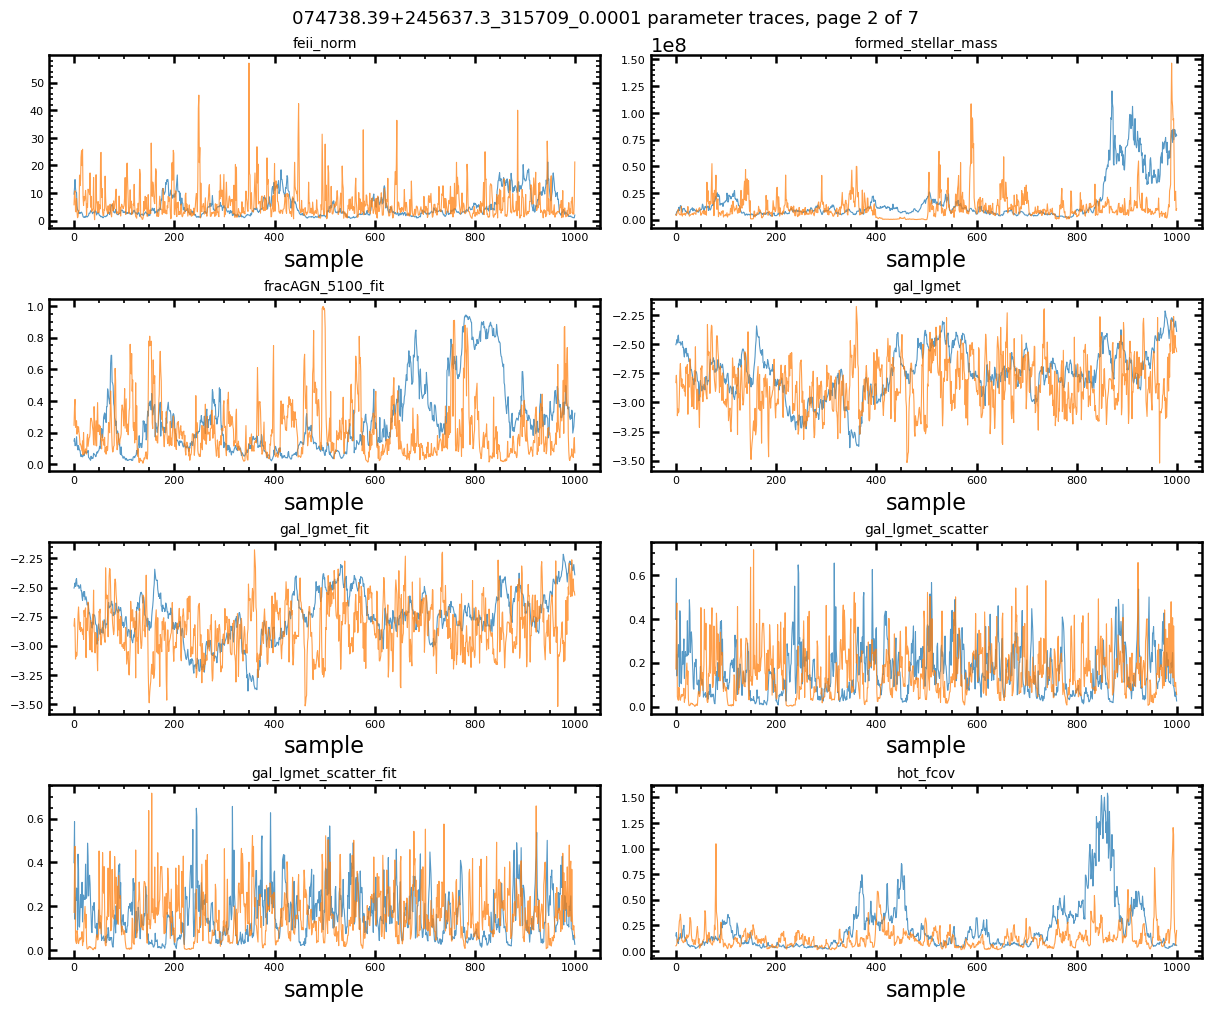

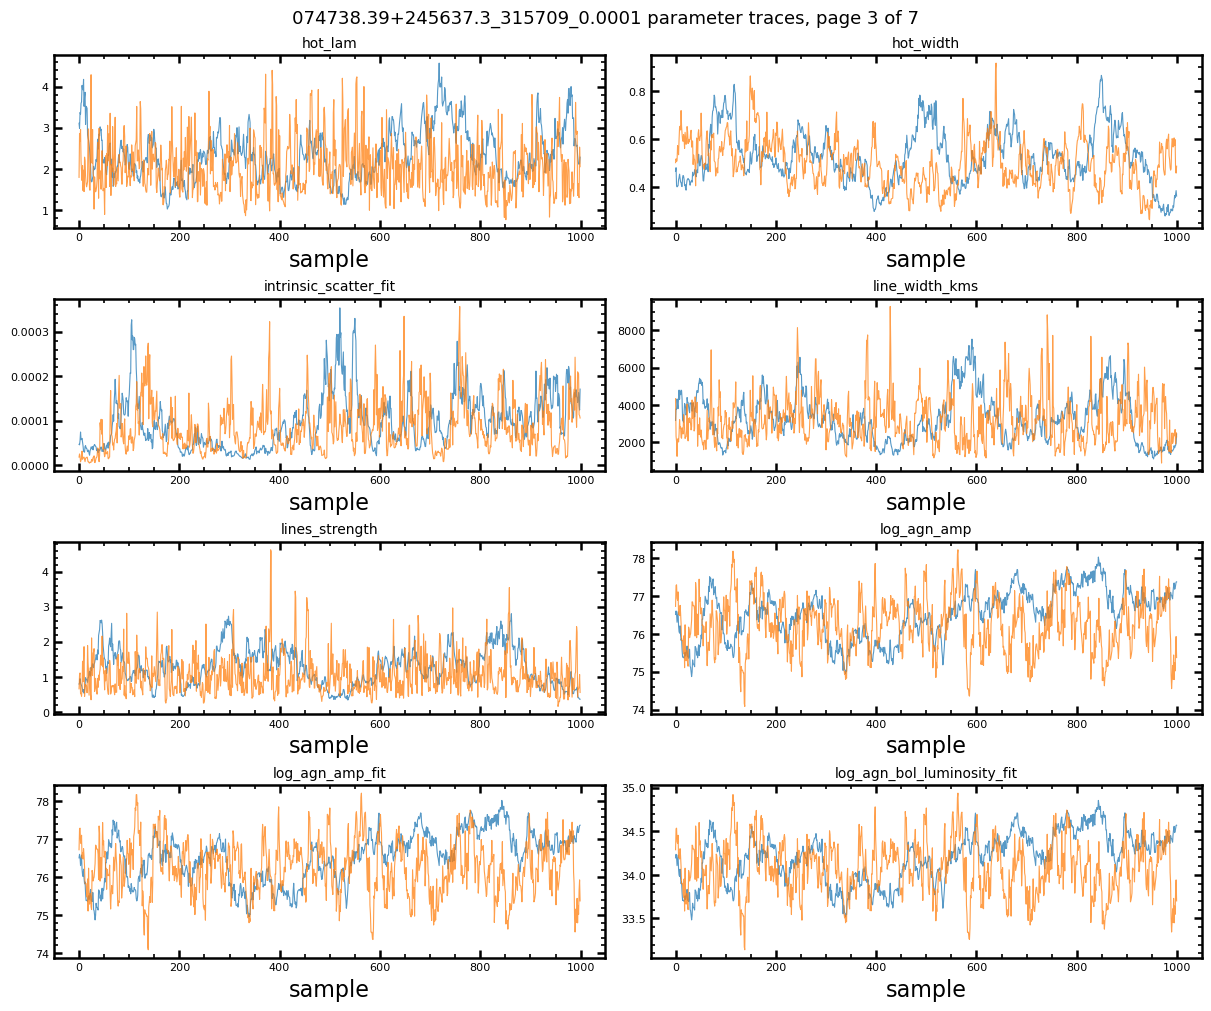

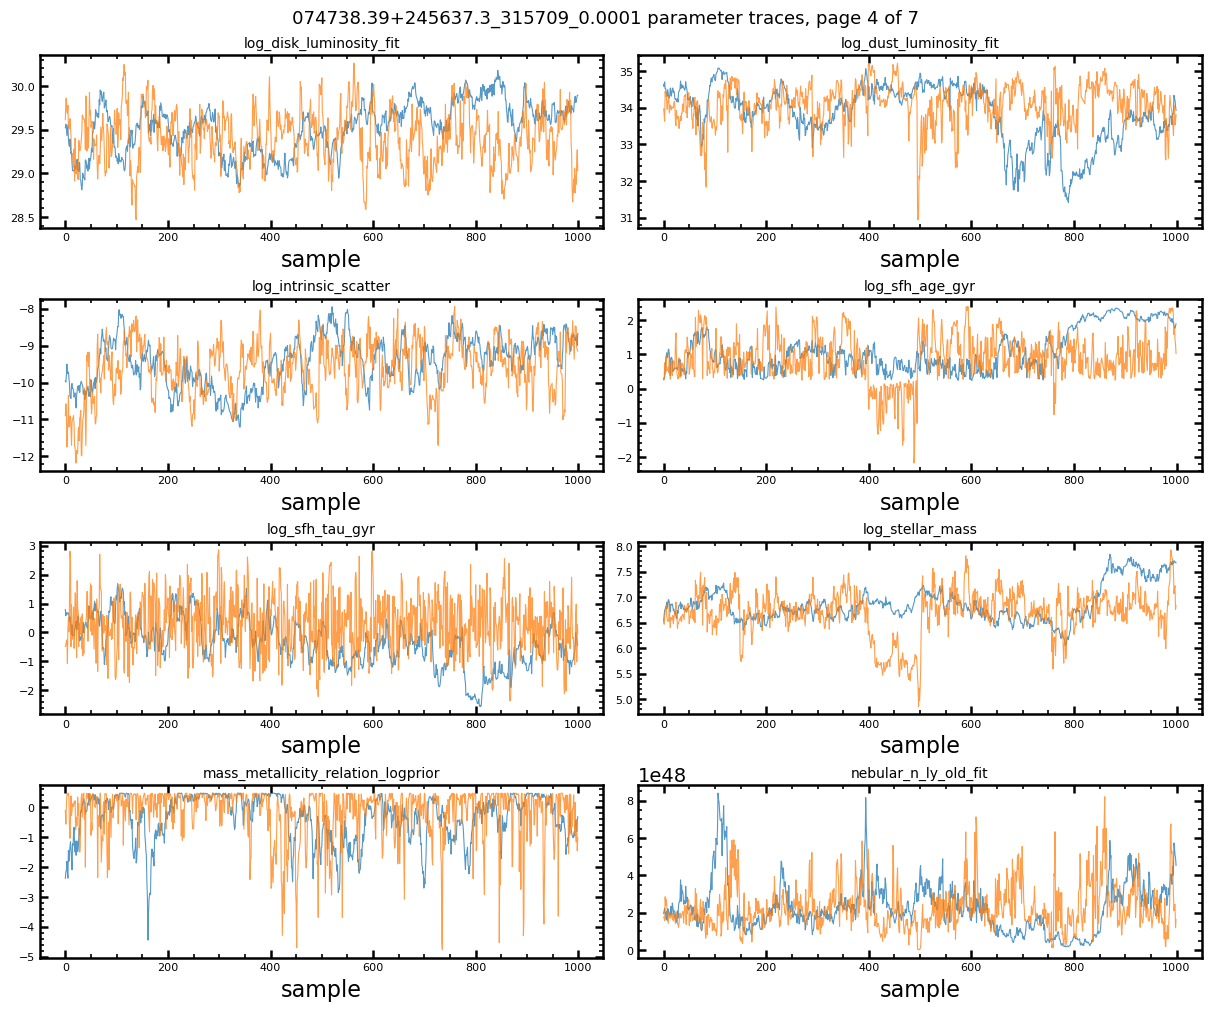

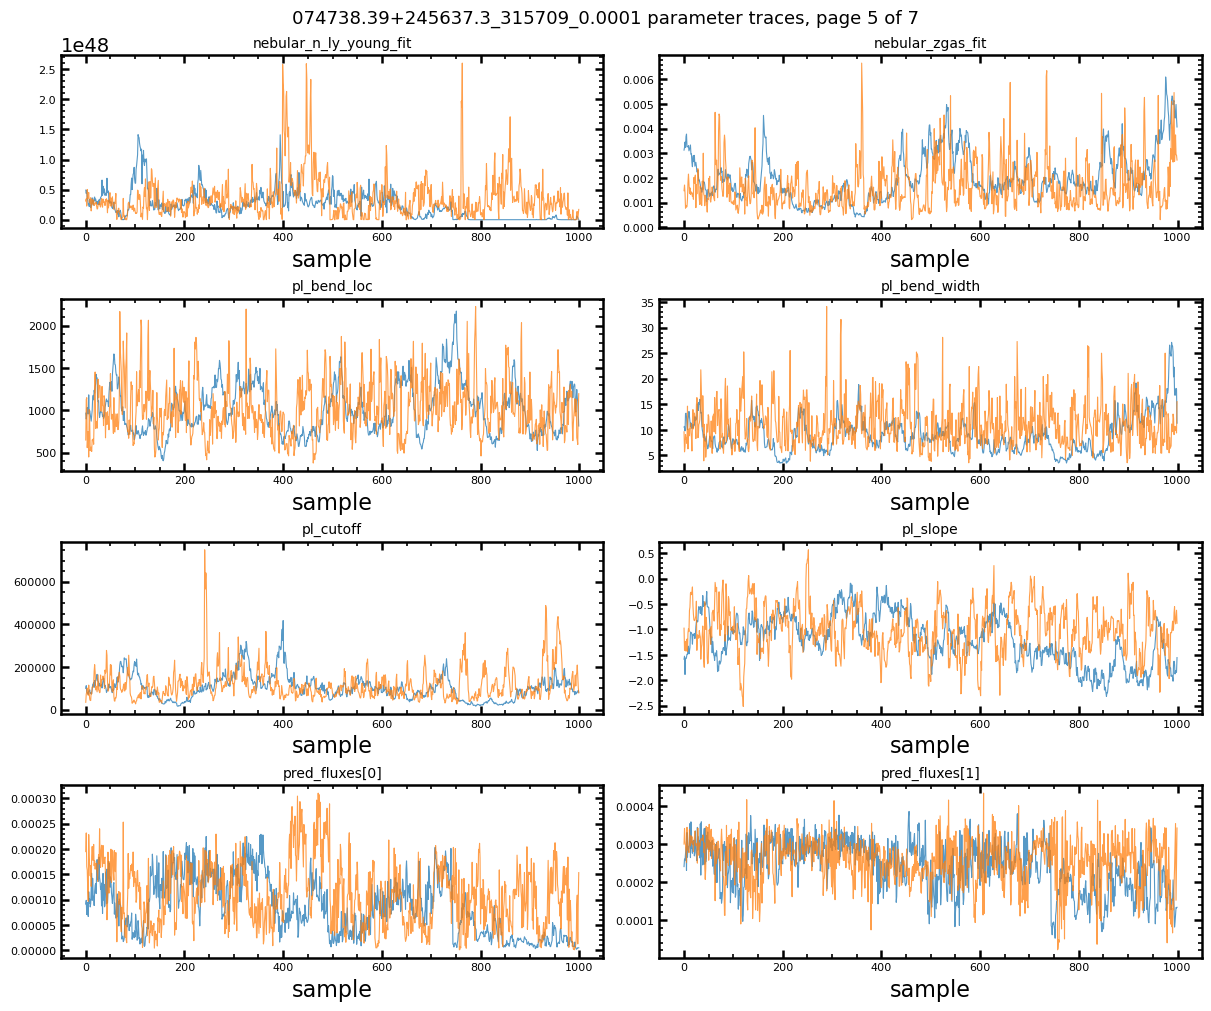

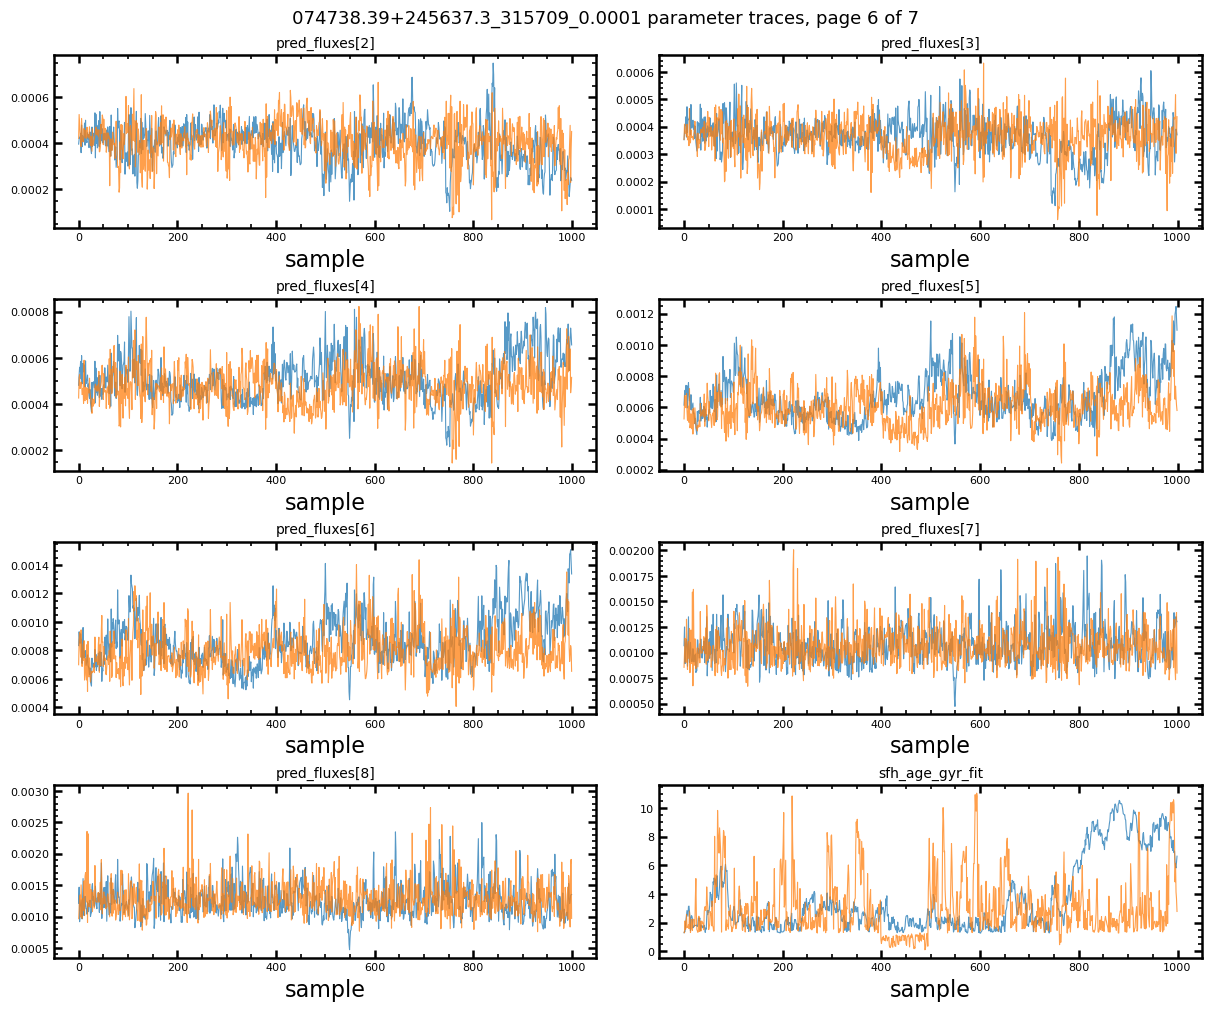

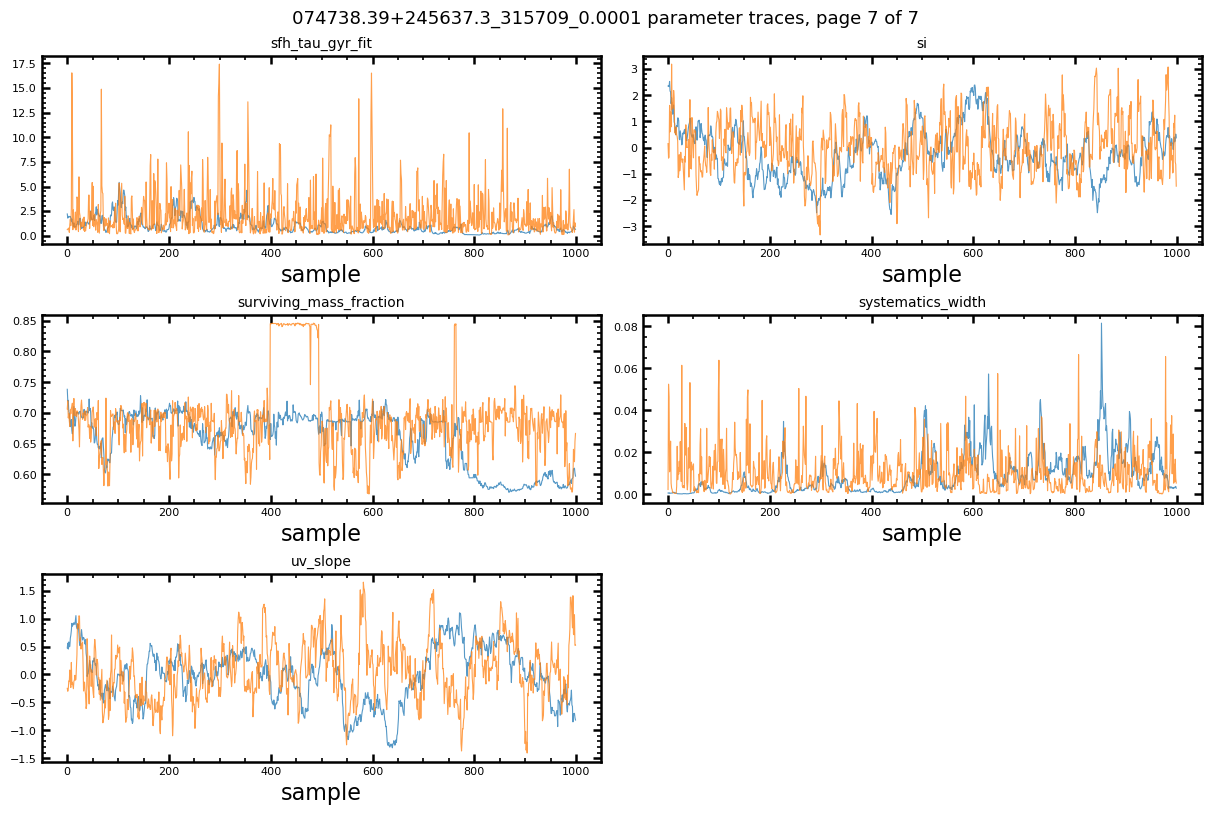

In [15]:
def plot_trace_pages(trace_columns, ncols=2, nrows=4, figsize=(12, 10)):
    if not trace_columns:
        raise ValueError("No trace columns to plot")

    per_page = ncols * nrows
    figures = []

    for page_start in range(0, len(trace_columns), per_page):
        page_columns = trace_columns[page_start:page_start + per_page]
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
        axes = np.asarray(axes).reshape(-1)

        for ax, (label, y) in zip(axes, page_columns):
            x = np.arange(y.shape[1])
            for chain_idx in range(y.shape[0]):
                ax.plot(x, y[chain_idx], lw=0.8, alpha=0.75, label=f"chain {chain_idx + 1}")
            ax.set_title(label, fontsize=10)
            ax.set_xlabel("sample")
            ax.tick_params(axis="both", labelsize=8)

        for ax in axes[len(page_columns):]:
            ax.set_visible(False)

        if page_start == 0 and page_columns:
            axes[0].legend(loc="best", fontsize=8, frameon=False)

        page = page_start // per_page + 1
        total_pages = math.ceil(len(trace_columns) / per_page)
        fig.suptitle(f"{target_object_id} parameter traces, page {page} of {total_pages}", fontsize=13)
        figures.append(fig)

    return figures


trace_figures = plot_trace_pages(trace_columns)

## Save Figures

In [16]:
from matplotlib.backends.backend_pdf import PdfPages

SAVE_FIGURES = True
output_dir = project_root / "notebook_outputs" / "14_chimera_parameter_trace_plots" / target_object_id

if SAVE_FIGURES:
    output_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = output_dir / "parameter_traces.pdf"
    with PdfPages(pdf_path) as pdf:
        for fig in trace_figures:
            pdf.savefig(fig, bbox_inches="tight")
    print(pdf_path)

    for i, fig in enumerate(trace_figures, start=1):
        out = output_dir / f"trace_page_{i:02d}.png"
        fig.savefig(out, dpi=180, bbox_inches="tight")
        print(out)

/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/parameter_traces.pdf
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/trace_page_01.png
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/trace_page_02.png
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/trace_page_03.png
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/trace_page_04.png
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/trace_page_05.png
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/trace_page_06.png
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.3

## Run Original GRAHSP

This section writes a one-object CIGALE-style photometry table and `pcigale.ini`, then launches the original GRAHSP sampler. Set `RUN_GRAHSP = False` to reuse an existing run in the output directory.

In [17]:
grahsp_output_dir = project_root / "notebook_outputs" / "14_chimera_parameter_trace_plots" / target_object_id / "grahsp"
grahsp_output_dir.mkdir(parents=True, exist_ok=True)

chimera_to_grahsp_filters = {
    "u_sdss": "u_sdss",
    "r_sdss": "r_sdss",
    "i_sdss": "i_sdss",
    "z_sdss": "z_sdss",
    "J_2mass": "J_2mass",
    "H_2mass": "H_2mass",
    "Ks_2mass": "Ks_2mass",
    "spitzer.irac.I1": "IRAC1",
    "spitzer.irac.I2": "IRAC2",
}

table_data = {
    "id": [str(row["id"])],
    "redshift": [float(row["redshift"])],
    "redshift_err": [0.0],
}
for chimera_name, grahsp_name in chimera_to_grahsp_filters.items():
    flux = float(row[chimera_name])
    err = float(row[f"{chimera_name}_err"])
    table_data[grahsp_name] = [flux if np.isfinite(flux) else -9999.0]
    table_data[f"{grahsp_name}_err"] = [err if np.isfinite(err) and err > 0 else -9999.0]

input_table = Table(table_data)
input_path = grahsp_output_dir / "chimera_object.ecsv"
input_table.write(input_path, format="ascii.ecsv", overwrite=True)

filters = list(chimera_to_grahsp_filters.values())
column_list = []
for name in filters:
    column_list.extend([name, f"{name}_err"])

pcigale_ini = f"""
data_file = {input_path}
column_list = {", ".join(column_list)}
creation_modules = sfh2exp, m2005, nebular, activate, activatelines, activategtorus, activatepl, activatebol, biattenuation, galdale2014, redshifting
analysis_method = pdf_analysis
cores = 1
cosmology = concordance

[statistics]
  exponent = 2
  systematics_width = 0.03
  variability_uncertainty = true
  attenuation_model_uncertainty = false
  Ly_break_uncertainty = false

[sed_creation_modules]
  [[sfh2exp]]
    tau_main = 500, 1500, 4000, 8000
    tau_burst = 50
    f_burst = 0.0, 0.01, 0.1
    age = 500, 1000, 3000, 6000, 9000, 12000
    burst_age = 20, 100
    sfr_0 = 1
    normalise = True

  [[m2005]]
    imf = 1
    metallicity = 0.02
    separation_age = 10

  [[nebular]]
    logU = -2.0
    zgas = 0.02
    ne = 100
    f_esc = 0.0
    f_dust = 0.0
    lines_width = 300
    emission = True

  [[activate]]
    fracAGN = -1

  [[activatelines]]
    AFeII = 5
    AGNtype = 1
    linewidth = 3000
    Alines = 1
    ABC = 0

  [[activategtorus]]
    fcov = 0.05, 0.2, 0.5
    Si = 0
    COOLlam = 17
    COOLwidth = 0.45
    HOTlam = 2.0
    HOTwidth = 0.5
    HOTfcov = 0.0, 0.5
    SiRatio = 0.29
    SiEmlam = 9841
    SiAbslam = 14224
    SiEmWidth = 1025.3
    SiAbsWidth = 1163.5

  [[activatepl]]
    plslope = -1.8
    plbendloc = 90
    plbendwidth = 0.5
    uvslope = 0
    cutoff = 10000

  [[activatebol]]

  [[biattenuation]]
    OPT_index = -1.2
    NIR_index = -3.0
    norm = 1.2
    lam_break = 1100
    E(B-V) = 0.001, 0.01, 0.1
    E(B-V)-AGN = 0.001, 0.03, 0.3, 1.0
    filters =

  [[galdale2014]]
    alpha = 2.0
    lam_max = -1

  [[redshifting]]
    redshift =

[analysis_configuration]
  analysed_variables = stellar.mass_total, stellar.mass_alive, sfh.sfr, sfh.sfr100Myrs, agn.lumBolBBB, agn.lumBolTOR, agn.fracAGNDale
  save_best_sed = False
  save_chi2 = False
  save_pdf = False
  lim_flag = False
  mock_flag = False
"""

config_path = grahsp_output_dir / "pcigale.ini"
config_path.write_text(textwrap.dedent(pcigale_ini).strip() + "\n")
print("Wrote", input_path)
print("Wrote", config_path)

Wrote /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/grahsp/chimera_object.ecsv
Wrote /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/grahsp/pcigale.ini


In [18]:
RUN_GRAHSP = True
GRAHSP_NUM_LIVE_POINTS = 800
GRAHSP_NUM_POSTERIOR_SAMPLES = 3000
MAKE_GRAHSP_PLOTS = False

cmd = [
    sys.executable,
    str(sampler_script),
    "analyse",
    "--cores", "1",
    "--num-live-points", str(GRAHSP_NUM_LIVE_POINTS),
    "--num-posterior-samples", str(GRAHSP_NUM_POSTERIOR_SAMPLES),
    "--mass-max", "13",
]
if MAKE_GRAHSP_PLOTS:
    cmd.append("--plot")

env = os.environ.copy()
env["PYTHONPATH"] = os.pathsep.join([str(cigale_root), str(src_root), env.get("PYTHONPATH", "")])
env["OMP_NUM_THREADS"] = "1"
env["HDF5_USE_FILE_LOCKING"] = "FALSE"
env["MPLCONFIGDIR"] = str(grahsp_output_dir / "mplconfig")
env["CACHE_MAX"] = "5000"
(grahsp_output_dir / "mplconfig").mkdir(exist_ok=True)

print("Working directory:", grahsp_output_dir)
print("Command:", " ".join(cmd))

if RUN_GRAHSP:
    completed = subprocess.run(cmd, cwd=grahsp_output_dir, env=env, text=True, capture_output=True)
    print(completed.stdout[-6000:])
    if completed.returncode != 0:
        print(completed.stderr[-6000:])
        raise RuntimeError(f"GRAHSP failed with return code {completed.returncode}")
else:
    print("RUN_GRAHSP is False; set it to True to launch the fitter.")

Working directory: /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/grahsp
Command: /home/nicho/miniconda3/envs/astro/bin/python /home/nicho/GRAHSP/sampler/dualsampler.py analyse --cores 1 --num-live-points 800 --num-posterior-samples 3000 --mass-max 13
ke=51.40..62.52 [50.9375..51.6399] | it/evals=4480/199499 eff=inf% N=800 
Z=44.6(0.06%) | Like=52.02..62.52 [51.9949..52.0190] | it/evals=4560/199499 eff=inf% N=800 
Z=45.1(0.08%) | Like=52.51..62.64 [52.5116..52.5201]*| it/evals=4640/199499 eff=inf% N=800 
Z=45.2(0.09%) | Like=52.58..62.64 [52.5840..52.5868]*| it/evals=4655/199499 eff=inf% N=800 
Z=45.6(0.13%) | Like=53.06..62.64 [53.0553..53.0614]*| it/evals=4720/199499 eff=inf% N=800 
Z=46.0(0.21%) | Like=53.46..62.64 [53.4624..53.4642]*| it/evals=4800/199499 eff=inf% N=800 
Z=46.2(0.25%) | Like=53.66..62.64 [53.6627..53.6640]*| it/evals=4834/199499 eff=inf% N=800 
Z=46.5(0.32%) | Like=53.97..62.64 [53.9680..53.9734]*| it

## Build GRAHSP Trace Columns

GRAHSP uses nested sampling, not multiple NUTS chains. These traces therefore show one ordered sequence from `chains/weighted_post.txt`; the x-axis is the sample/dead-point order written by UltraNest.

In [19]:
def read_grahsp_chain(chain_path):
    if not chain_path.is_file():
        raise FileNotFoundError(f"Missing GRAHSP chain file: {chain_path}")
    data = np.genfromtxt(chain_path, names=True, dtype=float, encoding=None)
    if data.ndim == 0:
        data = data.reshape(1)
    return data


def grahsp_chain_to_trace_columns(chain_data, skip=("weight", "logl"), drop_constant=True):
    columns = []
    dropped = []
    for name in chain_data.dtype.names:
        if name in skip:
            continue
        y = np.asarray(chain_data[name], dtype=float)[None, :]
        if not np.all(np.isfinite(y)):
            dropped.append((name, "non-finite values"))
            continue
        if drop_constant and np.nanmax(y) - np.nanmin(y) <= 1e-10:
            dropped.append((name, "constant"))
            continue
        columns.append((name, y))
    return columns, dropped


chain_dirs = sorted(grahsp_output_dir.glob("grahsp_*/chains"))
if not chain_dirs:
    raise FileNotFoundError(f"No GRAHSP chain directories found below {grahsp_output_dir}")
grahsp_chain_path = chain_dirs[-1] / "weighted_post.txt"

grahsp_chain_data = read_grahsp_chain(grahsp_chain_path)
grahsp_trace_columns, grahsp_dropped_trace_columns = grahsp_chain_to_trace_columns(grahsp_chain_data)

print("GRAHSP chain file:", grahsp_chain_path)
print(f"GRAHSP trace parameters plotted: {len(grahsp_trace_columns)}")
if grahsp_dropped_trace_columns:
    print(f"Dropped {len(grahsp_dropped_trace_columns)} constant or unsupported entries")
    print(grahsp_dropped_trace_columns[:20])

GRAHSP chain file: /home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/grahsp/grahsp_074738.39+245637.3_315709_0.0001_varV1_maxgal13/chains/weighted_post.txt
GRAHSP trace parameters plotted: 11
Dropped 1 constant or unsupported entries
[('redshift', 'constant')]


## Plot And Save GRAHSP Traces

/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/grahsp/trace_plots/grahsp_parameter_traces.pdf
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/grahsp/trace_plots/grahsp_trace_page_01.png
/home/nicho/GRAHSP/jaxsedfit/notebook_outputs/14_chimera_parameter_trace_plots/074738.39+245637.3_315709_0.0001/grahsp/trace_plots/grahsp_trace_page_02.png


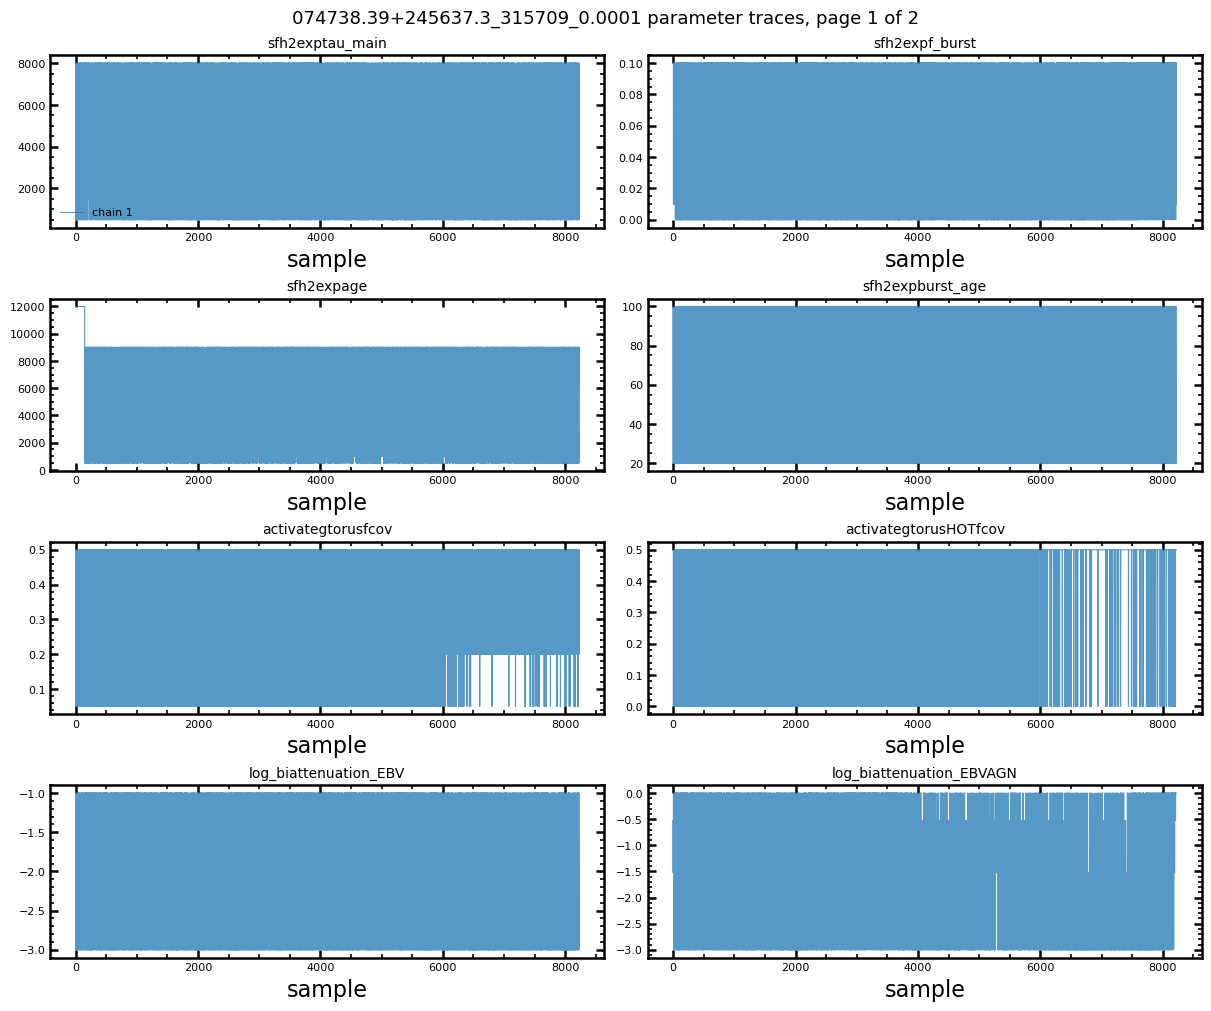

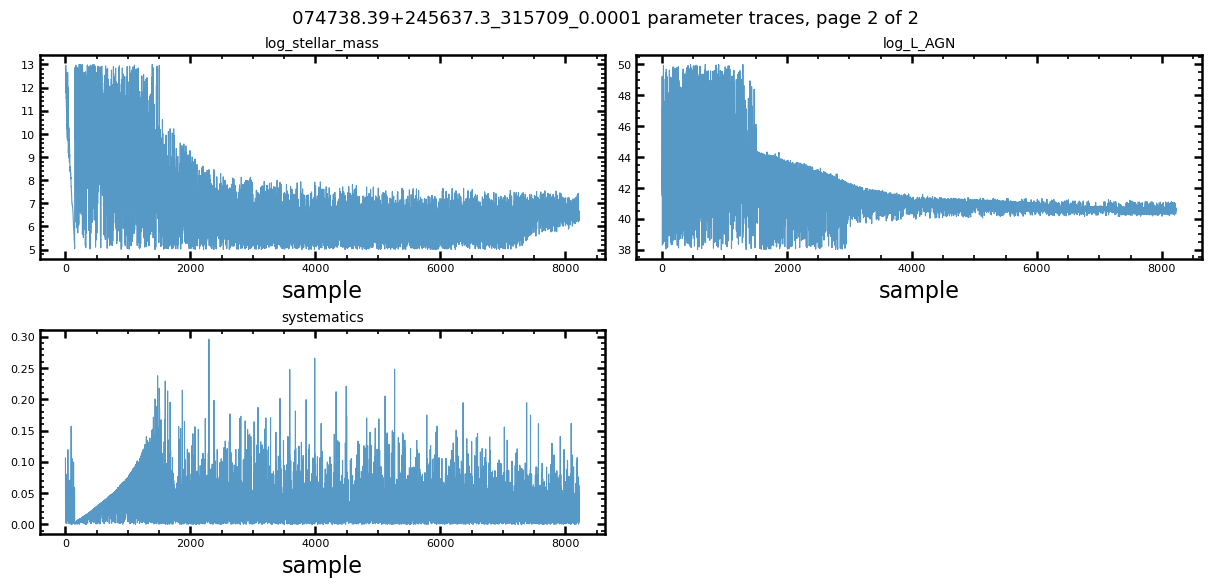

In [20]:
grahsp_trace_figures = plot_trace_pages(grahsp_trace_columns)

grahsp_trace_output_dir = project_root / "notebook_outputs" / "14_chimera_parameter_trace_plots" / target_object_id / "grahsp" / "trace_plots"
grahsp_trace_output_dir.mkdir(parents=True, exist_ok=True)

grahsp_pdf_path = grahsp_trace_output_dir / "grahsp_parameter_traces.pdf"
with PdfPages(grahsp_pdf_path) as pdf:
    for fig in grahsp_trace_figures:
        pdf.savefig(fig, bbox_inches="tight")
print(grahsp_pdf_path)

for i, fig in enumerate(grahsp_trace_figures, start=1):
    out = grahsp_trace_output_dir / f"grahsp_trace_page_{i:02d}.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print(out)